In [ ]:
# 06 — Modelling

Predicts the four-class shot outcome (SQ2) from pre-shot tactical context.

Two decisions shape this notebook:

1. Train/test split is by match, not by shot. Shots from one match are
   highly correlated, so a random split would place near-duplicate rows on
   both sides and inflate test scores.
2. Training uses a random subsample of the training matches. Going from
   200k to 1M rows did not improve macro F1, so the extra compute buys
   nothing.

Accuracy is reported but is not the headline metric: predicting the
majority class alone already gives ~77.8%. Macro F1 is used instead,
because it weights all four outcome classes equally.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
from pathlib import Path

from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, accuracy_score)
from xgboost import XGBClassifier

sns.set_style("whitegrid")

CWD = Path.cwd()
PROJECT_ROOT = CWD if (CWD / "data").exists() else CWD.parent
PROCESSED = PROJECT_ROOT / "data" / "processed"
FIGURES = PROJECT_ROOT / "figures"

data = pd.read_parquet(PROCESSED / "model_data.parquet")
print("Model data:", data.shape)

Model data: (5207197, 21)


In [2]:
CATEGORICAL = ["shot_type", "direction", "direction_pattern", "to_opponent_wing",
               "prev_shot_type", "prev_direction", "prev_depth",
               "serve_direction", "pressure_context", "Surface", "gender"]
NUMERIC = ["shot_number", "is_approach", "prev_approach",
           "is_serving", "is_second_serve"]

# Missing values become their own category rather than being dropped:
# "no previous shot" is a real situation, not absent data.
for col in CATEGORICAL:
    data[col] = data[col].fillna("none").astype(str)
for col in NUMERIC:
    data[col] = data[col].fillna(0).astype(float)

# Split on match_id so no match appears in both train and test.
matches = data["match_id"].unique()
rng = np.random.default_rng(42)
rng.shuffle(matches)
test_matches = set(matches[:int(len(matches) * 0.2)])

train = data[~data["match_id"].isin(test_matches)]
test = data[data["match_id"].isin(test_matches)]

print(f"Train matches: {train['match_id'].nunique():,}  rows: {len(train):,}")
print(f"Test matches:  {test['match_id'].nunique():,}  rows: {len(test):,}")

Train matches: 7,340  rows: 4,180,050
Test matches:  1,834  rows: 1,027,147


In [3]:
# Subsample the training rows. Benchmarking showed no macro F1 gain beyond
# roughly 200k-500k rows, so this is a compute decision, not a data limitation.
SAMPLE_SIZE = 500_000
train_sample = train.sample(min(SAMPLE_SIZE, len(train)), random_state=42)

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
encoder.fit(train_sample[CATEGORICAL])

def build_matrix(df):
    """Combine one-hot categorical columns with the numeric ones."""
    return sp.hstack([encoder.transform(df[CATEGORICAL]),
                      sp.csr_matrix(df[NUMERIC].values)]).tocsr()

X_train = build_matrix(train_sample)
X_test = build_matrix(test)
y_train = train_sample["target_outcome"].values
y_test = test["target_outcome"].values

print("Feature matrix:", X_train.shape)

Feature matrix: (500000, 76)


In [4]:
# Everything else must be judged against this, not against zero.
dummy = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
dummy_pred = dummy.predict(X_test)

print(f"Baseline accuracy: {accuracy_score(y_test, dummy_pred):.4f}")
print(f"Baseline macro F1: {f1_score(y_test, dummy_pred, average='macro'):.4f}")

Baseline accuracy: 0.7780
Baseline macro F1: 0.2188


In [5]:
# class_weight='balanced' makes the model pay equal attention to rare classes.
# Accuracy will drop sharply as a result - that is expected, not a failure.
# max_iter is raised because the default does not converge on this data.
logreg = LogisticRegression(max_iter=1000, class_weight="balanced", n_jobs=-1)
logreg.fit(X_train, y_train)
logreg_pred = logreg.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, logreg_pred):.4f}")
print(f"Macro F1: {f1_score(y_test, logreg_pred, average='macro'):.4f}\n")
print(classification_report(y_test, logreg_pred))

Accuracy: 0.3777
Macro F1: 0.3193

                precision    recall  f1-score   support

  forced_error       0.16      0.65      0.26     72994
       in_play       0.88      0.33      0.48    799131
unforced_error       0.13      0.40      0.20     89266
        winner       0.24      0.57      0.34     65756

      accuracy                           0.38   1027147
     macro avg       0.35      0.49      0.32   1027147
  weighted avg       0.72      0.38      0.43   1027147



In [6]:
# Trees can capture interactions a linear model cannot, for example
# "down-the-line is only risky when the incoming ball was deep".
rf = RandomForestClassifier(n_estimators=200, max_depth=14,
                            min_samples_leaf=50, class_weight="balanced",
                            n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, rf_pred):.4f}")
print(f"Macro F1: {f1_score(y_test, rf_pred, average='macro'):.4f}\n")
print(classification_report(y_test, rf_pred))

Accuracy: 0.4166
Macro F1: 0.3313

                precision    recall  f1-score   support

  forced_error       0.18      0.62      0.28     72994
       in_play       0.88      0.39      0.54    799131
unforced_error       0.13      0.32      0.19     89266
        winner       0.21      0.66      0.32     65756

      accuracy                           0.42   1027147
     macro avg       0.35      0.50      0.33   1027147
  weighted avg       0.72      0.42      0.48   1027147



In [7]:
# XGBoost needs integer labels, so we map the four classes and keep the
# mapping to translate predictions back for reporting.
CLASSES = ["in_play", "unforced_error", "forced_error", "winner"]
label_to_int = {name: i for i, name in enumerate(CLASSES)}

# Sample weights replicate class_weight='balanced', which XGBoost lacks.
class_counts = pd.Series(y_train).value_counts()
weights = pd.Series(y_train).map(len(y_train) / (len(CLASSES) * class_counts)).values

xgb = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                    tree_method="hist", n_jobs=-1, random_state=42)
xgb.fit(X_train, pd.Series(y_train).map(label_to_int).values,
        sample_weight=weights)

xgb_pred = np.array(CLASSES)[xgb.predict(X_test)]

print(f"Accuracy: {accuracy_score(y_test, xgb_pred):.4f}")
print(f"Macro F1: {f1_score(y_test, xgb_pred, average='macro'):.4f}\n")
print(classification_report(y_test, xgb_pred))

Accuracy: 0.3965
Macro F1: 0.3378

                precision    recall  f1-score   support

  forced_error       0.19      0.64      0.29     72994
       in_play       0.88      0.35      0.50    799131
unforced_error       0.14      0.47      0.21     89266
        winner       0.25      0.59      0.35     65756

      accuracy                           0.40   1027147
     macro avg       0.36      0.51      0.34   1027147
  weighted avg       0.73      0.40      0.45   1027147



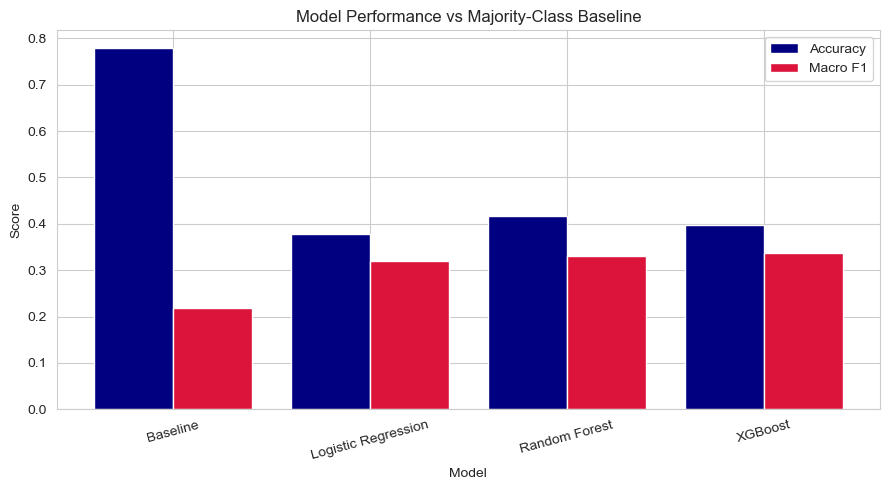

              model  accuracy  macro_f1
           Baseline    0.7780    0.2188
Logistic Regression    0.3777    0.3193
      Random Forest    0.4166    0.3313
            XGBoost    0.3965    0.3378


In [8]:
results = pd.DataFrame([
    {"model": "Baseline", "accuracy": accuracy_score(y_test, dummy_pred),
     "macro_f1": f1_score(y_test, dummy_pred, average="macro")},
    {"model": "Logistic Regression", "accuracy": accuracy_score(y_test, logreg_pred),
     "macro_f1": f1_score(y_test, logreg_pred, average="macro")},
    {"model": "Random Forest", "accuracy": accuracy_score(y_test, rf_pred),
     "macro_f1": f1_score(y_test, rf_pred, average="macro")},
    {"model": "XGBoost", "accuracy": accuracy_score(y_test, xgb_pred),
     "macro_f1": f1_score(y_test, xgb_pred, average="macro")},
])

plt.figure(figsize=(9, 5))
x = np.arange(len(results))
plt.bar(x - 0.2, results["accuracy"], width=0.4, color="navy", label="Accuracy")
plt.bar(x + 0.2, results["macro_f1"], width=0.4, color="crimson", label="Macro F1")
plt.xticks(x, results["model"], rotation=15)
plt.title("Model Performance vs Majority-Class Baseline")
plt.xlabel("Model")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES / "model_comparison.png", dpi=150)
plt.show()

print(results.round(4).to_string(index=False))

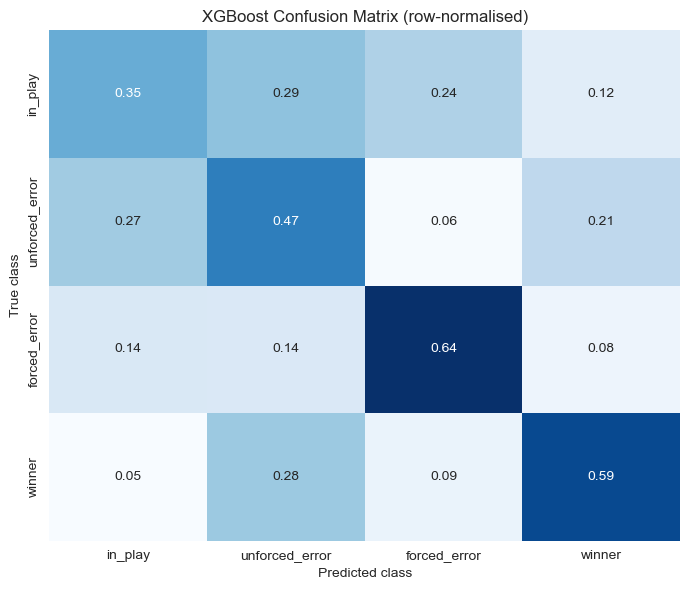

In [9]:
# Which classes the best model confuses tells us more than a single score.
best_pred = xgb_pred
cm = confusion_matrix(y_test, best_pred, labels=CLASSES, normalize="true")

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=CLASSES, yticklabels=CLASSES, cbar=False)
plt.title("XGBoost Confusion Matrix (row-normalised)")
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.tight_layout()
plt.savefig(FIGURES / "confusion_matrix_xgb.png", dpi=150)
plt.show()

In [10]:
import pickle

with open(PROCESSED / "model_artifacts.pkl", "wb") as f:
    pickle.dump({"encoder": encoder, "xgb": xgb, "classes": CLASSES,
                 "categorical": CATEGORICAL, "numeric": NUMERIC}, f)

test.sample(min(100_000, len(test)), random_state=42).to_parquet(
    PROCESSED / "test_sample.parquet", index=False)

results.to_csv(FIGURES / "model_results.csv", index=False)
print("Saved model artifacts for SHAP analysis.")

Saved model artifacts for SHAP analysis.


In [11]:
from sklearn.metrics import log_loss

# The weighted model above answers "which class is this shot?".
# This one answers "what is the probability of each outcome?", which is what
# the research question actually asks. Class weights are removed because they
# deliberately distort the class priors and therefore ruin calibration.
xgb_prob = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                         tree_method="hist", n_jobs=-1, random_state=42)
xgb_prob.fit(X_train, pd.Series(y_train).map(label_to_int).values)

probabilities = xgb_prob.predict_proba(X_test)
y_test_int = pd.Series(y_test).map(label_to_int).values

# Baseline for probabilities: always predict the overall class frequencies.
priors = pd.Series(y_train).value_counts(normalize=True).reindex(CLASSES).values
baseline_probs = np.tile(priors, (len(y_test), 1))

print(f"Baseline log loss: {log_loss(y_test_int, baseline_probs):.4f}")
print(f"XGBoost log loss:  {log_loss(y_test_int, probabilities):.4f}")
print(f"Accuracy (unweighted): {accuracy_score(y_test_int, xgb_prob.predict(X_test)):.4f}")

Baseline log loss: 0.7715
XGBoost log loss:  0.6435
Accuracy (unweighted): 0.7831


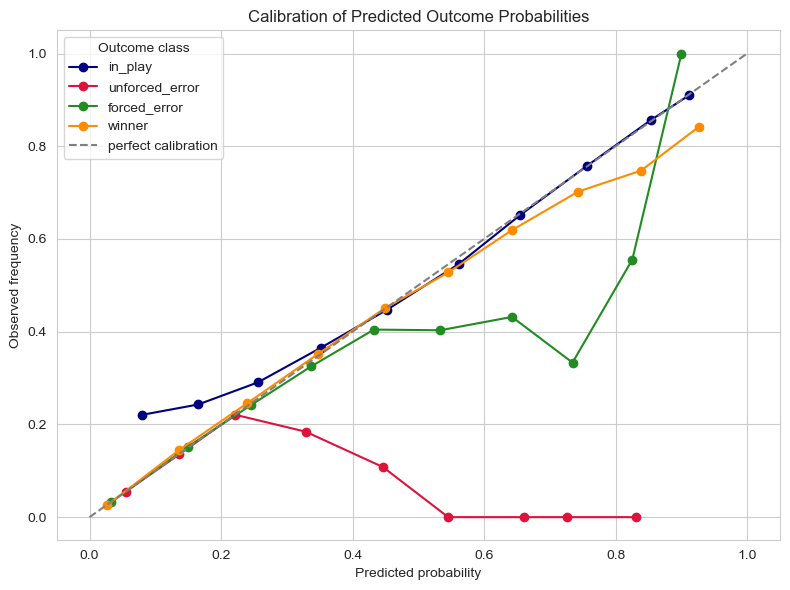

In [12]:
from sklearn.calibration import calibration_curve

# A well-calibrated model is one where, among shots it gives a 20% chance of
# being a winner, about 20% actually are. This matters more than accuracy
# when the output is used to compare tactical risk.
plt.figure(figsize=(8, 6))
colours = ["navy", "crimson", "forestgreen", "darkorange"]

for i, (name, colour) in enumerate(zip(CLASSES, colours)):
    true_freq, predicted_prob = calibration_curve(
        (y_test_int == i).astype(int), probabilities[:, i], n_bins=10)
    plt.plot(predicted_prob, true_freq, marker="o", color=colour, label=name)

plt.plot([0, 1], [0, 1], linestyle="--", color="grey", label="perfect calibration")
plt.title("Calibration of Predicted Outcome Probabilities")
plt.xlabel("Predicted probability")
plt.ylabel("Observed frequency")
plt.legend(title="Outcome class")
plt.tight_layout()
plt.savefig(FIGURES / "calibration_curves.png", dpi=150)
plt.show()

In [13]:
import pickle

# SHAP is run on the unweighted model, because its outputs are probabilities
# we can interpret directly as risk.
with open(PROCESSED / "model_artifacts.pkl", "wb") as f:
    pickle.dump({"encoder": encoder, "xgb": xgb_prob, "classes": CLASSES,
                 "categorical": CATEGORICAL, "numeric": NUMERIC}, f)

test.sample(min(100_000, len(test)), random_state=42).to_parquet(
    PROCESSED / "test_sample.parquet", index=False)

results.to_csv(FIGURES / "model_results.csv", index=False)
print("Saved unweighted model for SHAP analysis.")

Saved unweighted model for SHAP analysis.


In [14]:
# The calibration curve hides how many shots sit behind each point.
# A bin holding 40 shots looks the same as one holding 400,000.
for i, name in enumerate(CLASSES):
    counts, edges = np.histogram(probabilities[:, i], bins=10, range=(0, 1))
    above_half = counts[5:].sum()
    print(f"{name:<16} shots with predicted prob > 0.5: {above_half:>9,} "
          f"({100 * above_half / len(probabilities):.3f}%)")

in_play          shots with predicted prob > 0.5:   976,958 (95.114%)
unforced_error   shots with predicted prob > 0.5:        14 (0.001%)
forced_error     shots with predicted prob > 0.5:       585 (0.057%)
winner           shots with predicted prob > 0.5:    15,812 (1.539%)


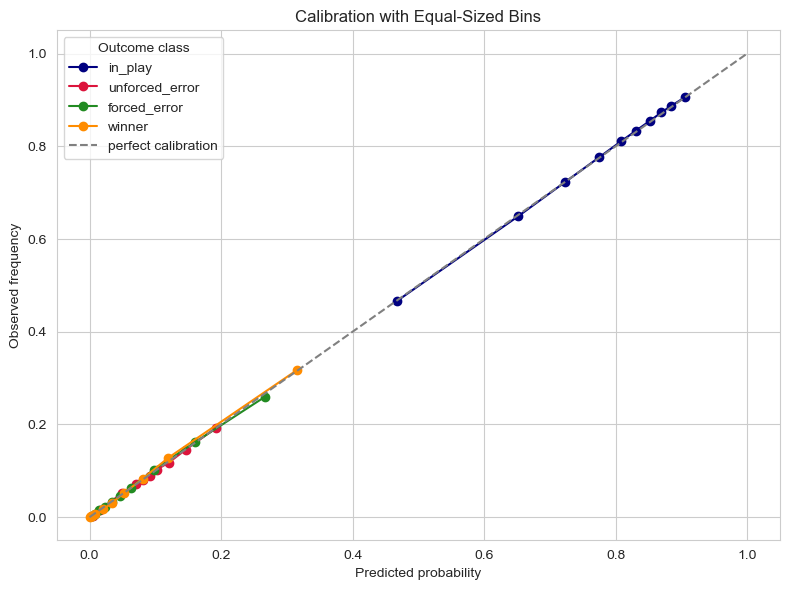

In [15]:
# Quantile bins put an equal number of shots in each point, so every marker
# is backed by the same amount of evidence.
plt.figure(figsize=(8, 6))
colours = ["navy", "crimson", "forestgreen", "darkorange"]

for i, (name, colour) in enumerate(zip(CLASSES, colours)):
    true_freq, predicted_prob = calibration_curve(
        (y_test_int == i).astype(int), probabilities[:, i],
        n_bins=10, strategy="quantile")
    plt.plot(predicted_prob, true_freq, marker="o", color=colour, label=name)

plt.plot([0, 1], [0, 1], linestyle="--", color="grey", label="perfect calibration")
plt.title("Calibration with Equal-Sized Bins")
plt.xlabel("Predicted probability")
plt.ylabel("Observed frequency")
plt.legend(title="Outcome class")
plt.tight_layout()
plt.savefig(FIGURES / "calibration_quantile.png", dpi=150)
plt.show()